# Heuristic annealing schedule

In [5]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [4]:
numerical_var_energies = pd.read_pickle("../estimation_variance/var_energies.pkl")

Prepare the avg table

In [6]:
df = numerical_var_energies.copy()

df = df[["n", "beta", "instance", "var_energy"]].copy()
df["n"] = df["n"].astype(int)
df["beta"] = df["beta"].astype(float)
df["instance"] = df["instance"].astype(int)
df["var_energy"] = pd.to_numeric(df["var_energy"], errors="coerce")

agg = (
    df
    .groupby(["n", "beta"], as_index=False)
    .agg(
        V=("var_energy", "mean"),
        V_std=("var_energy", "std"),
        count=("var_energy", "count"),
    )
)

agg["V_sem"] = agg["V_std"] / np.sqrt(agg["count"])
agg = agg[(agg["count"] > 0) & np.isfinite(agg["V"]) & (agg["V"] > 0)].copy()
agg["V_over_n"] = agg["V"] / agg["n"]

In [9]:
agg["V_over_n"]

0      1.000000
1      0.993797
2      0.984989
3      0.973628
4      0.959791
         ...   
775    0.014508
776    0.004551
777    0.000992
778    0.000393
779    0.000046
Name: V_over_n, Length: 780, dtype: float64

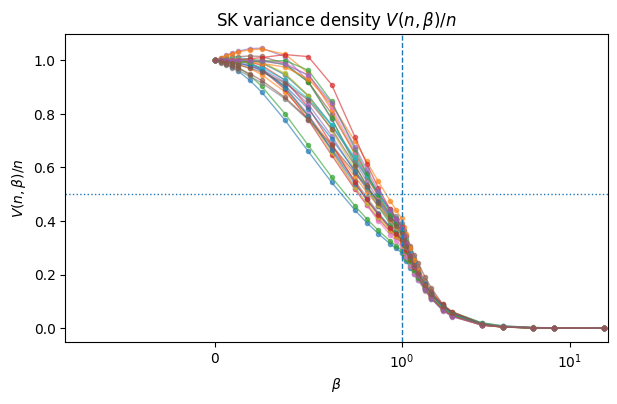

In [8]:
plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    plt.plot(g["beta"], g["V_over_n"], marker="o", linewidth=1, markersize=3, alpha=0.6, label=f"n={n}")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.axhline(0.5, linestyle=":", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title(r"SK variance density $V(n,\beta)/n$")
plt.show()

In [10]:
def fit_high_free(data):
    d = data[(data["beta"] < 1.0) & (data["V"] > 0)].copy()
    x = np.log(d["n"].to_numpy())
    y = np.log(d["V"].to_numpy())
    a, logC = np.polyfit(x, y, deg=1)
    return {"C_lt": np.exp(logC), "a_lt": a}

def fit_low_free(data):
    d = data[(data["beta"] >= 1.0) & (data["V"] > 0)].copy()
    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        logC, a, logtau, q = theta
        tau = np.exp(logtau)
        pred = logC + a * np.log(n) - q * np.log1p((beta - 1.0) / tau)
        return pred - y

    theta0 = [np.log(0.5), 1.0, np.log(1.0), 3.0]
    res = least_squares(residual, theta0)
    logC, a, logtau, q = res.x

    return {"C_ge": np.exp(logC), "a_ge": a, "tau": np.exp(logtau), "q": q, "cost": res.cost}

fit_A_lt = fit_high_free(agg)
fit_A_ge = fit_low_free(agg)

fit_A_lt, fit_A_ge

({'C_lt': np.float64(0.601631955461543),
  'a_lt': np.float64(1.0770462416370135)},
 {'C_ge': np.float64(0.4595039921010902),
  'a_ge': np.float64(0.9218846252699084),
  'tau': np.float64(1.2775044320231699),
  'q': np.float64(3.500144745282401),
  'cost': np.float64(6.727299679787751)})

In [11]:
def fit_high_a1(data):
    d = data[(data["beta"] < 1.0) & (data["V"] > 0)].copy()
    C = np.mean(d["V"].to_numpy() / d["n"].to_numpy())
    return {"C_lt": C, "a_lt": 1.0}

def fit_low_a1(data):
    d = data[(data["beta"] >= 1.0) & (data["V"] > 0)].copy()
    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        logC, logtau, q = theta
        tau = np.exp(logtau)
        pred = logC + np.log(n) - q * np.log1p((beta - 1.0) / tau)
        return pred - y

    theta0 = [np.log(0.5), np.log(1.0), 3.0]
    res = least_squares(residual, theta0)
    logC, logtau, q = res.x

    return {"C_ge": np.exp(logC), "a_ge": 1.0, "tau": np.exp(logtau), "q": q, "cost": res.cost}

fit_B_lt = fit_high_a1(agg)
fit_B_ge = fit_low_a1(agg)

fit_B_lt, fit_B_ge

({'C_lt': np.float64(0.7891437972673597), 'a_lt': 1.0},
 {'C_ge': np.float64(0.370698805505),
  'a_ge': 1.0,
  'tau': np.float64(1.2775044372701845),
  'q': np.float64(3.500144750737327),
  'cost': np.float64(7.0313557741835275)})

In [12]:
fit_C_lt = {"C_lt": 0.5, "a_lt": 1.0}
fit_C_ge = fit_low_a1(agg)

fit_C_lt, fit_C_ge

({'C_lt': 0.5, 'a_lt': 1.0},
 {'C_ge': np.float64(0.370698805505),
  'a_ge': 1.0,
  'tau': np.float64(1.2775044372701845),
  'q': np.float64(3.500144750737327),
  'cost': np.float64(7.0313557741835275)})

In [13]:
def predict_piecewise(data, fit_lt, fit_ge):
    n = data["n"].to_numpy(dtype=float)
    beta = data["beta"].to_numpy(dtype=float)
    pred = np.empty(len(data), dtype=float)

    mask_lt = beta < 1.0
    mask_ge = ~mask_lt

    pred[mask_lt] = fit_lt["C_lt"] * n[mask_lt] ** fit_lt["a_lt"]

    C = fit_ge["C_ge"]
    a = fit_ge["a_ge"]
    tau = fit_ge["tau"]
    q = fit_ge["q"]

    pred[mask_ge] = C * n[mask_ge] ** a * (1.0 + (beta[mask_ge] - 1.0) / tau) ** (-q)

    return pred

def log_rmse(y, yhat):
    return np.sqrt(np.mean((np.log(yhat) - np.log(y)) ** 2))

pred_A = predict_piecewise(agg, fit_A_lt, fit_A_ge)
pred_B = predict_piecewise(agg, fit_B_lt, fit_B_ge)
pred_C = predict_piecewise(agg, fit_C_lt, fit_C_ge)

print("A free exponents log-RMSE:", log_rmse(agg["V"].to_numpy(), pred_A))
print("B fixed a=1 log-RMSE:     ", log_rmse(agg["V"].to_numpy(), pred_B))
print("C fixed HT n/2 log-RMSE:  ", log_rmse(agg["V"].to_numpy(), pred_C))

A free exponents log-RMSE: 0.28827289130204115
B fixed a=1 log-RMSE:      0.2939532508312379
C fixed HT n/2 log-RMSE:   0.40421128173070003


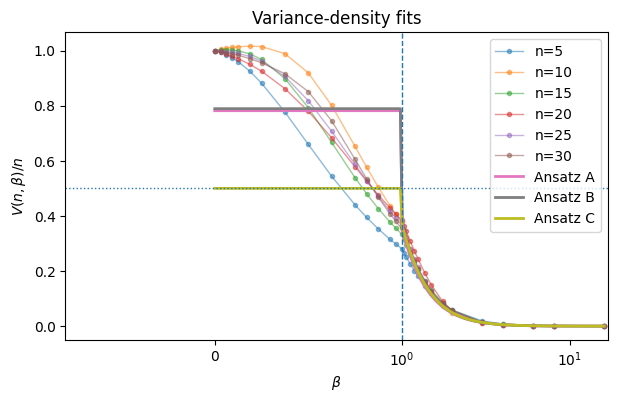

In [14]:
beta_plot = np.linspace(0.0, 16.0, 1000)
n_ref = 30

plot_df = pd.DataFrame({"n": n_ref, "beta": beta_plot})

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.5, label=f"n={n}")

plt.plot(beta_plot, predict_piecewise(plot_df, fit_A_lt, fit_A_ge) / n_ref, linewidth=2, label="Ansatz A")
plt.plot(beta_plot, predict_piecewise(plot_df, fit_B_lt, fit_B_ge) / n_ref, linewidth=2, label="Ansatz B")
plt.plot(beta_plot, predict_piecewise(plot_df, fit_C_lt, fit_C_ge) / n_ref, linewidth=2, label="Ansatz C")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.axhline(0.5, linestyle=":", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.legend()
plt.title(r"Variance-density fits")
plt.show()

In [16]:
rows = []

for n_min in [5, 10, 15, 20]:
    d = agg[agg["n"] >= n_min].copy()

    A_lt = fit_high_free(d)
    A_ge = fit_low_free(d)

    B_lt = fit_high_a1(d)
    B_ge = fit_low_a1(d)

    pred_A = predict_piecewise(d, A_lt, A_ge)
    pred_B = predict_piecewise(d, B_lt, B_ge)

    rows.append({
        "n_min": n_min,
        "model": "A_free",
        "a_lt": A_lt["a_lt"],
        "a_ge": A_ge["a_ge"],
        "q": A_ge["q"],
        "tau": A_ge["tau"],
        "log_rmse": log_rmse(d["V"].to_numpy(), pred_A),
    })

    rows.append({
        "n_min": n_min,
        "model": "B_a1",
        "a_lt": 1.0,
        "a_ge": 1.0,
        "q": B_ge["q"],
        "tau": B_ge["tau"],
        "log_rmse": log_rmse(d["V"].to_numpy(), pred_B),
    })

stability = pd.DataFrame(rows)
print(stability)

   n_min   model      a_lt      a_ge         q       tau  log_rmse
0      5  A_free  1.077046  0.921885  3.500145  1.277504  0.288273
1      5    B_a1  1.000000  1.000000  3.500145  1.277504  0.293953
2     10  A_free  1.064855  0.898410  3.483867  1.236230  0.276327
3     10    B_a1  1.000000  1.000000  3.483867  1.236230  0.280469
4     15  A_free  1.085600  0.850816  3.545560  1.253927  0.263959
5     15    B_a1  1.000000  1.000000  3.545560  1.253927  0.267876
6     20  A_free  1.093788  0.747693  3.587428  1.242588  0.253037
7     20    B_a1  1.000000  1.000000  3.587428  1.242588  0.256576


In [17]:
def V_model_continuous_a1(theta, n, beta):
    c0, c1, c2, log_tau, q = theta
    tau = np.exp(log_tau)

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(c0 + c1 * beta[mask] + c2 * beta[mask] ** 2)
    v[~mask] = np.exp(c0 + c1 + c2) * (1.0 + (beta[~mask] - 1.0) / tau) ** (-q)

    return n * v


def fit_continuous_a1(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_continuous_a1(theta, n, beta)
        return np.log(pred) - y

    theta0 = [
        np.log(1.0),     # v(0) near 1
        -1.0,            # decrease with beta
        0.0,             # curvature
        np.log(1.25),    # tau, from your current fit
        3.5,             # q, from your current fit
    ]

    res = least_squares(residual, theta0)
    return res.x, res.cost


theta_D, cost_D = fit_continuous_a1(agg)

c0, c1, c2, log_tau, q = theta_D
tau = np.exp(log_tau)

print("cost =", cost_D)
print("v(0) =", np.exp(c0))
print("v(1) =", np.exp(c0 + c1 + c2))
print("tau =", tau)
print("q =", q)

cost = 8.286201235231857
v(0) = 0.9907431115575055
v(1) = 0.36367290126369217
tau = 1.3057134214092014
q = 3.523177039508145


In [18]:
pred_D = V_model_continuous_a1(theta_D, agg["n"].to_numpy(), agg["beta"].to_numpy())

print("D continuous high-temp branch log-RMSE:", log_rmse(agg["V"].to_numpy(), pred_D))

D continuous high-temp branch log-RMSE: 0.14576237454819346


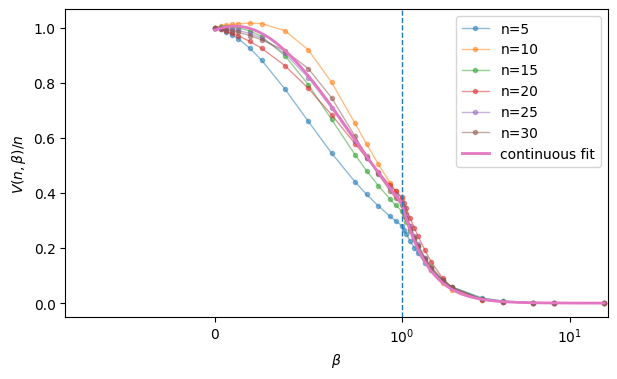

In [19]:
beta_plot = np.linspace(0.0, 16.0, 1000)
n_ref = 30
V_plot = V_model_continuous_a1(theta_D, np.full_like(beta_plot, n_ref), beta_plot)

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.5, label=f"n={n}")

plt.plot(beta_plot, V_plot / n_ref, linewidth=2, label="continuous fit")
plt.axvline(1.0, linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.legend()
plt.show()

In [20]:
def V_model_continuous_linear_a1(theta, n, beta):
    c0, c1, log_tau, q = theta
    tau = np.exp(log_tau)

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(c0 + c1 * beta[mask])
    v[~mask] = np.exp(c0 + c1) * (1.0 + (beta[~mask] - 1.0) / tau) ** (-q)

    return n * v


def fit_continuous_linear_a1(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_continuous_linear_a1(theta, n, beta)
        return np.log(pred) - y

    theta0 = [
        np.log(1.0),      # c0: v(0)
        np.log(0.36),     # c1 roughly gives v(1)/v(0)
        np.log(1.3),      # tau
        3.5,              # q
    ]

    res = least_squares(residual, theta0)
    return res.x, res.cost


theta_E, cost_E = fit_continuous_linear_a1(agg)

c0, c1, log_tau, q = theta_E
tau = np.exp(log_tau)

pred_E = V_model_continuous_linear_a1(theta_E, agg["n"].to_numpy(), agg["beta"].to_numpy())

print("cost =", cost_E)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_E))
print("v(0) =", np.exp(c0))
print("v(1) =", np.exp(c0 + c1))
print("tau =", tau)
print("q =", q)

cost = 11.226455922531775
log-RMSE = 0.1696637392513443
v(0) = 1.167545591816752
v(1) = 0.39797742004336434
tau = 1.177599105712083
q = 3.416629252438488


In [21]:
print("quadratic log-RMSE:", log_rmse(agg["V"].to_numpy(), pred_D))
print("linear log-RMSE:   ", log_rmse(agg["V"].to_numpy(), pred_E))

quadratic log-RMSE: 0.14576237454819346
linear log-RMSE:    0.1696637392513443


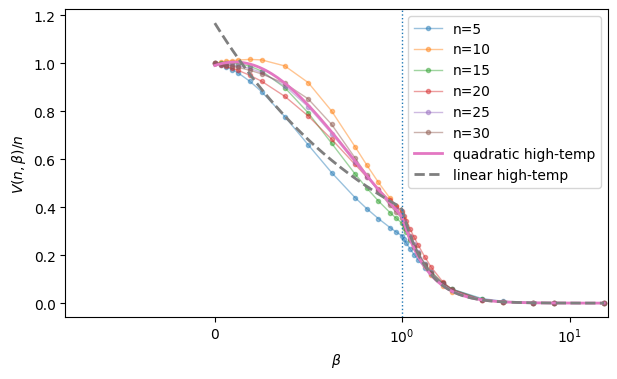

In [22]:
beta_plot = np.linspace(0.0, 16.0, 1000)
n_ref = 30

V_quad = V_model_continuous_a1(theta_D, np.full_like(beta_plot, n_ref), beta_plot)
V_lin = V_model_continuous_linear_a1(theta_E, np.full_like(beta_plot, n_ref), beta_plot)

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.45, label=f"n={n}")

plt.plot(beta_plot, V_quad / n_ref, linewidth=2, label="quadratic high-temp")
plt.plot(beta_plot, V_lin / n_ref, linewidth=2, linestyle="--", label="linear high-temp")

plt.axvline(1.0, linestyle=":", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.legend()
plt.show()

In [23]:
def V_model_endpoint_quad_a1(theta, n, beta):
    log_v0, log_v1, kappa, log_tau, q = theta
    v0 = np.exp(log_v0)
    v1 = np.exp(log_v1)
    tau = np.exp(log_tau)

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = v0 * np.exp(np.log(v1 / v0) * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * (1.0 + (beta[~mask] - 1.0) / tau) ** (-q)

    return n * v


def fit_endpoint_quad_a1(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_endpoint_quad_a1(theta, n, beta)
        return np.log(pred) - y

    theta0 = [
        np.log(0.99),     # v0
        np.log(0.36),     # v1
        0.0,              # curvature
        np.log(1.30),     # tau
        3.52,             # q
    ]

    res = least_squares(residual, theta0)
    return res.x, res.cost


theta_F, cost_F = fit_endpoint_quad_a1(agg)
pred_F = V_model_endpoint_quad_a1(theta_F, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v0, log_v1, kappa, log_tau, q = theta_F

print("cost =", cost_F)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_F))
print("v0 =", np.exp(log_v0))
print("v1 =", np.exp(log_v1))
print("kappa =", kappa)
print("tau =", np.exp(log_tau))
print("q =", q)

cost = 8.286201235235826
log-RMSE = 0.14576237454822838
v0 = 0.9907430712270134
v1 = 0.3636728361867612
kappa = 1.273640960525058
tau = 1.305714206095057
q = 3.523177907186749


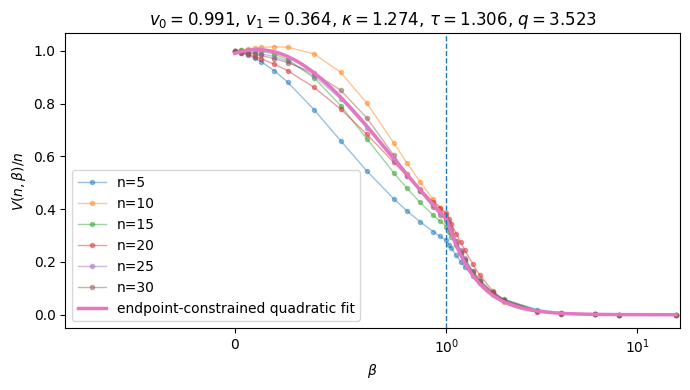

In [24]:
import numpy as np
import matplotlib.pyplot as plt

beta_plot = np.linspace(0.0, 16.0, 2000)
n_ref = 30

V_fit_plot = V_model_endpoint_quad_a1(theta_F, np.full_like(beta_plot, n_ref), beta_plot)

log_v0, log_v1, kappa, log_tau, q = theta_F
v0 = np.exp(log_v0)
v1 = np.exp(log_v1)
tau = np.exp(log_tau)

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.45, label=f"n={n}")

plt.plot(beta_plot, V_fit_plot / n_ref, linewidth=2.5, label="endpoint-constrained quadratic fit")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title(
    rf"$v_0={v0:.3f}$, $v_1={v1:.3f}$, $\kappa={kappa:.3f}$, "
    rf"$\tau={tau:.3f}$, $q={q:.3f}$"
)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
def V_model_v0_fixed(theta, n, beta):
    log_v1, kappa, log_tau, q = theta
    v1 = np.exp(log_v1)
    tau = np.exp(log_tau)

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(log_v1 * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * (1.0 + (beta[~mask] - 1.0) / tau) ** (-q)

    return n * v


def fit_v0_fixed(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_v0_fixed(theta, n, beta)
        return np.log(pred) - y

    theta0 = [np.log(0.364), 1.27, np.log(1.31), 3.52]
    res = least_squares(residual, theta0)

    return res.x, res.cost


theta_G, cost_G = fit_v0_fixed(agg)
pred_G = V_model_v0_fixed(theta_G, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v1_G, kappa_G, log_tau_G, q_G = theta_G

print("Reduced model 1: v0 fixed, q free")
print("cost =", cost_G)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_G))
print("v0 =", 1.0)
print("v1 =", np.exp(log_v1_G))
print("kappa =", kappa_G)
print("tau =", np.exp(log_tau_G))
print("q =", q_G)


def V_model_v0_q_fixed(theta, n, beta):
    log_v1, kappa, log_tau = theta
    v1 = np.exp(log_v1)
    tau = np.exp(log_tau)
    q = 3.5

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(log_v1 * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * (1.0 + (beta[~mask] - 1.0) / tau) ** (-q)

    return n * v


def fit_v0_q_fixed(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_v0_q_fixed(theta, n, beta)
        return np.log(pred) - y

    theta0 = [np.log(0.364), 1.27, np.log(1.31)]
    res = least_squares(residual, theta0)

    return res.x, res.cost


theta_H, cost_H = fit_v0_q_fixed(agg)
pred_H = V_model_v0_q_fixed(theta_H, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v1_H, kappa_H, log_tau_H = theta_H

print("Reduced model 2: v0 fixed, q fixed")
print("cost =", cost_H)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_H))
print("v0 =", 1.0)
print("v1 =", np.exp(log_v1_H))
print("kappa =", kappa_H)
print("tau =", np.exp(log_tau_H))
print("q =", 3.5)

Reduced model 1: v0 fixed, q free
cost = 8.290190027707743
log-RMSE = 0.14579745370527883
v0 = 1.0
v1 = 0.364061042526027
kappa = 1.2431533888756048
tau = 1.3041257924958916
q = 3.5218866990121116
Reduced model 2: v0 fixed, q fixed
cost = 8.295139108377327
log-RMSE = 0.14584096632077614
v0 = 1.0
v1 = 0.36515017757837354
kappa = 1.234930969062032
tau = 1.2860992780901652
q = 3.5


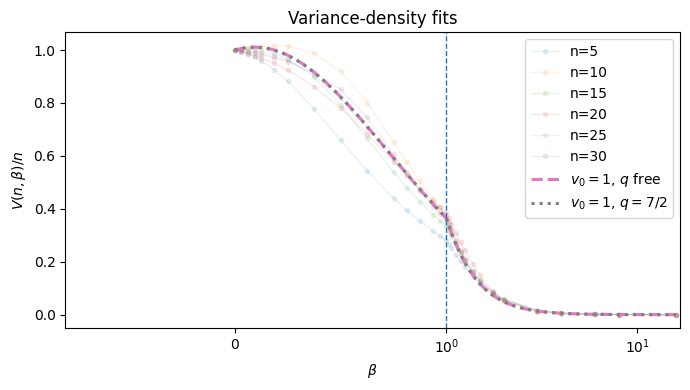

In [28]:
beta_plot = np.linspace(0.0, 16.0, 2000)
n_ref = 30

V_full = V_model_endpoint_quad_a1(theta_F, np.full_like(beta_plot, n_ref), beta_plot)
V_G = V_model_v0_fixed(theta_G, np.full_like(beta_plot, n_ref), beta_plot)
V_H = V_model_v0_q_fixed(theta_H, np.full_like(beta_plot, n_ref), beta_plot)

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.1, label=f"n={n}")

# plt.plot(beta_plot, V_full / n_ref, linewidth=2.5, label="full endpoint fit")
plt.plot(beta_plot, V_G / n_ref, linewidth=2.2, linestyle="--", label=r"$v_0=1$, $q$ free")
plt.plot(beta_plot, V_H / n_ref, linewidth=2.2, linestyle=":", label=r"$v_0=1$, $q=7/2$")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title("Variance-density fits")
plt.legend()
plt.tight_layout()
plt.show()

No tau, q free
cost = 9.944776461270896
log-RMSE = 0.1596853995322413
v0 = 1.0
v1 = 0.3940675468330172
kappa = 1.0251464761437252
q = 3.168990494862935
No tau, q fixed
cost = 26.390646077803915
log-RMSE = 0.26013135773378093
v0 = 1.0
v1 = 0.493531599639417
kappa = 0.4056370681434065
q = 3.5


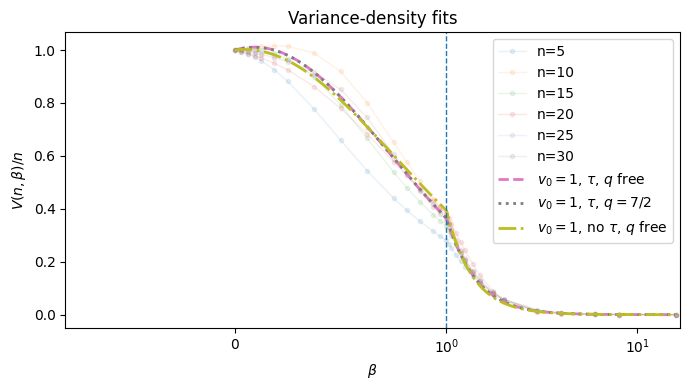

In [32]:
def V_model_no_tau(theta, n, beta):
    log_v1, kappa, q = theta
    v1 = np.exp(log_v1)

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(log_v1 * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * beta[~mask] ** (-q)

    return n * v


def fit_no_tau(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_no_tau(theta, n, beta)
        return np.log(pred) - y

    theta0 = [np.log(0.364), 1.27, 3.5]
    res = least_squares(residual, theta0)

    return res.x, res.cost


theta_I, cost_I = fit_no_tau(agg)
pred_I = V_model_no_tau(theta_I, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v1_I, kappa_I, q_I = theta_I

print("No tau, q free")
print("cost =", cost_I)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_I))
print("v0 =", 1.0)
print("v1 =", np.exp(log_v1_I))
print("kappa =", kappa_I)
print("q =", q_I)

def V_model_no_tau_q_fixed(theta, n, beta):
    log_v1, kappa = theta
    v1 = np.exp(log_v1)
    q = 3.5

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(log_v1 * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * beta[~mask] ** (-q)

    return n * v


def fit_no_tau_q_fixed(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_no_tau_q_fixed(theta, n, beta)
        return np.log(pred) - y

    theta0 = [np.log(0.364), 1.27]
    res = least_squares(residual, theta0)

    return res.x, res.cost


theta_J, cost_J = fit_no_tau_q_fixed(agg)
pred_J = V_model_no_tau_q_fixed(theta_J, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v1_J, kappa_J = theta_J

print("No tau, q fixed")
print("cost =", cost_J)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_J))
print("v0 =", 1.0)
print("v1 =", np.exp(log_v1_J))
print("kappa =", kappa_J)
print("q =", 3.5)

beta_plot = np.linspace(0.0, 16.0, 2000)
n_ref = 30

V_full = V_model_endpoint_quad_a1(theta_F, np.full_like(beta_plot, n_ref), beta_plot)
V_G = V_model_v0_fixed(theta_G, np.full_like(beta_plot, n_ref), beta_plot)
V_H = V_model_v0_q_fixed(theta_H, np.full_like(beta_plot, n_ref), beta_plot)
V_I = V_model_no_tau(theta_I, np.full_like(beta_plot, n_ref), beta_plot)
V_J = V_model_no_tau_q_fixed(theta_J, np.full_like(beta_plot, n_ref), beta_plot)

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.1, label=f"n={n}")

# plt.plot(beta_plot, V_full / n_ref, linewidth=2.2, label="full")
plt.plot(beta_plot, V_G / n_ref, linewidth=2.0, linestyle="--", label=r"$v_0=1$, $\tau$, $q$ free")
plt.plot(beta_plot, V_H / n_ref, linewidth=2.0, linestyle=":", label=r"$v_0=1$, $\tau$, $q=7/2$")
plt.plot(beta_plot, V_I / n_ref, linewidth=2.0, linestyle="-.", label=r"$v_0=1$, no $\tau$, $q$ free")
# plt.plot(beta_plot, V_J / n_ref, linewidth=2.0, linestyle=(0, (3, 1, 1, 1)), label=r"$v_0=1$, no $\tau$, $q=7/2$")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title("Variance-density fits")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
def V_model_no_tau_q4(theta, n, beta):
    log_v1, kappa = theta
    v1 = np.exp(log_v1)

    n = np.asarray(n, dtype=float)
    beta = np.asarray(beta, dtype=float)

    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0

    v[mask] = np.exp(log_v1 * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * beta[~mask] ** (-4.0)

    return n * v


def fit_no_tau_q4(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()

    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        pred = V_model_no_tau_q4(theta, n, beta)
        return np.log(pred) - y

    theta0 = [np.log(0.4), 1.0]
    res = least_squares(residual, theta0)

    return res.x, res.cost


theta_K, cost_K = fit_no_tau_q4(agg)
pred_K = V_model_no_tau_q4(theta_K, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v1_K, kappa_K = theta_K

print("No tau, q = 4")
print("cost =", cost_K)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_K))
print("v0 =", 1.0)
print("v1 =", np.exp(log_v1_K))
print("kappa =", kappa_K)
print("q =", 4.0)

print("full endpoint:             ", log_rmse(agg["V"].to_numpy(), V_model_endpoint_quad_a1(theta_F, agg["n"].to_numpy(), agg["beta"].to_numpy())))
print("v0 fixed, tau, q free:    ", log_rmse(agg["V"].to_numpy(), pred_G))
print("v0 fixed, tau, q=7/2:     ", log_rmse(agg["V"].to_numpy(), pred_H))
print("v0 fixed, no tau, q free: ", log_rmse(agg["V"].to_numpy(), pred_I))
print("v0 fixed, no tau, q=4:    ", log_rmse(agg["V"].to_numpy(), pred_K))

No tau, q = 4
cost = 113.5992127877337
log-RMSE = 0.5397036527475618
v0 = 1.0
v1 = 0.6933630838953436
kappa = -0.5301508967265472
q = 4.0
full endpoint:              0.14576237454822838
v0 fixed, tau, q free:     0.14579745370527883
v0 fixed, tau, q=7/2:      0.14584096632077614
v0 fixed, no tau, q free:  0.1596853995322413
v0 fixed, no tau, q=4:     0.5397036527475618


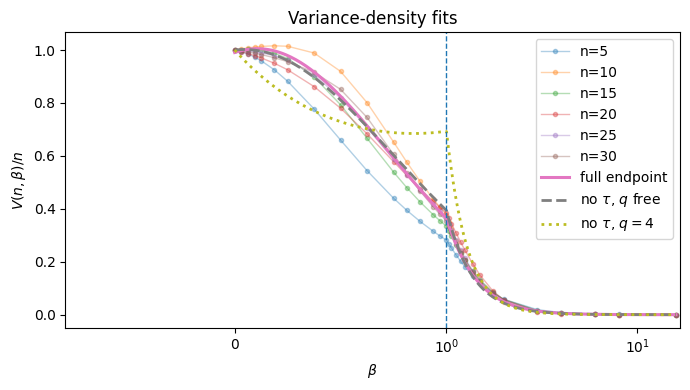

In [34]:
beta_plot = np.linspace(0.0, 16.0, 2000)
n_ref = 30

V_full = V_model_endpoint_quad_a1(theta_F, np.full_like(beta_plot, n_ref), beta_plot)
V_I = V_model_no_tau(theta_I, np.full_like(beta_plot, n_ref), beta_plot)
V_K = V_model_no_tau_q4(theta_K, np.full_like(beta_plot, n_ref), beta_plot)

plt.figure(figsize=(7, 4))

for n, g in agg.groupby("n"):
    if n in [5, 10, 15, 20, 25, 30]:
        plt.plot(g["beta"], g["V"] / g["n"], marker="o", linewidth=1, markersize=3, alpha=0.35, label=f"n={n}")

plt.plot(beta_plot, V_full / n_ref, linewidth=2.2, label="full endpoint")
plt.plot(beta_plot, V_I / n_ref, linewidth=2.0, linestyle="--", label=r"no $\tau$, $q$ free")
plt.plot(beta_plot, V_K / n_ref, linewidth=2.0, linestyle=":", label=r"no $\tau$, $q=4$")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title("Variance-density fits")
plt.legend()
plt.tight_layout()
plt.show()